# NB08 — Baseline ML Models (Random Split)

**Project:** Evolutionary Computation for Sepsis Mortality Prediction
**Input:** `data/processed/features_curated.parquet`, `data/processed/split_random.csv` (70/10/20 train/val/test)
**Output:** `baseline_cv_results.csv`, `baseline_test_predictions.csv`, `baseline_test_metrics.csv`, `NB08_calibration_curves.pdf`

---

### Purpose
Train three standard ML classifiers — Logistic Regression (LR), Random Forest (RF),
and XGBoost (XGB) — on the curated 58-feature set using the 70% train split from NB07.
Additionally, Platt-scaled variants of LR and RF are fitted using the 10% validation
set to provide properly calibrated baselines for comparison with GP. These models establish
black-box performance benchmarks against which the GP-evolved symbolic score (NB10) will
be compared in NB11.

### Model configuration

| Model | Key settings | Class imbalance |
|---|---|---|
| Logistic Regression (LR) | `C=1.0`, `solver='lbfgs'`, `max_iter=1000` | `class_weight='balanced'` |
| Random Forest (RF) | `n_estimators=300`, `min_samples_leaf=5` | `class_weight='balanced'` |
| XGBoost (XGB) | `n_estimators=300`, `max_depth=6`, `lr=0.05` | `scale_pos_weight` = neg/pos ratio |
| LR_platt | LR + Platt sigmoid calibration on validation set | — |
| RF_platt | RF + Platt sigmoid calibration on validation set | — |

StandardScaler fitted inside each CV fold for LR only (Pipeline). Tree-based models require no scaling.
Platt scaling uses `CalibratedClassifierCV(cv='prefit')` fitted on the 10% validation set — separate
from the training set to prevent calibration overfitting.

### Why class_weight='balanced' + Platt scaling
`class_weight='balanced'` optimises class separation for imbalanced clinical data but systematically
distorts predicted probabilities away from the true 16.88% prevalence — degrading ECE by design.
The Platt-scaled variants restore probability calibration post-hoc. This allows a fair comparison:
GP's calibration advantage is measured against both the standard and properly-calibrated baselines.

### Metrics
AUROC, AUPRC, Brier score, ECE (10-bin), calibration slope, calibration intercept,
sensitivity, specificity, F1. Threshold-dependent metrics use Youden's J optimal threshold.
ECE computed via `src.metrics.compute_ece` (shared utility — consistent last-bin boundary).

### Deliverables

| # | File | Description |
|---|---|---|
| 1 | `baseline_cv_results.csv` | OOF 5-fold CV metrics for LR, RF, XGB |
| 2 | `baseline_test_predictions.csv` | Test-set predicted probabilities: patientunitstayid + lr_pred + rf_pred + xgb_pred + lr_platt_pred + rf_platt_pred |
| 3 | `baseline_test_metrics.csv` | Test-set metrics for LR, RF, XGB, LR_platt, RF_platt (+ APACHE-IV reference) |
| 4 | `NB08_calibration_curves.pdf/.png` | 10-bin calibration curves for all 5 models + APACHE-IV |

---

## Cell 1 — Load inputs and prepare train/val/test arrays

**Plan.** Load `features_curated.parquet` and `split_random.csv`. Align patient rows
with split labels to produce `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`
from the 58 `MODELLING_COLS`. Compute `scale_pos_weight` for XGBoost from the training set.
Assert zero NaN in all feature arrays before modelling.

In [10]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import json

_nb_dir   = Path().resolve()
PROJECT   = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
DATA_PROC = PROJECT / "data" / "processed"
TABLES    = PROJECT / "results" / "tables"
FIGURES   = PROJECT / "results" / "figures"

# ── shared metric utility ─────────────────────────────────────────────────────
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.metrics import compute_ece

SEED = 42

# ── Load ──────────────────────────────────────────────────────────────────────
feat  = pd.read_parquet(DATA_PROC / "features_curated.parquet")
split = pd.read_csv(DATA_PROC / "split_random.csv")

with open(DATA_PROC / "feature_config.json") as f:
    cfg = json.load(f)
MODELLING_COLS = cfg["MODELLING_COLS"]

# ── Align split labels ────────────────────────────────────────────────────────
feat = feat.merge(split[["patientunitstayid", "split"]], on="patientunitstayid")
assert feat.shape[0] == 11164

train_df = feat[feat["split"] == "train"].reset_index(drop=True)
val_df   = feat[feat["split"] == "val"].reset_index(drop=True)
test_df  = feat[feat["split"] == "test"].reset_index(drop=True)

X_train = train_df[MODELLING_COLS].to_numpy(dtype=np.float64)
y_train = train_df["hospital_mortality"].to_numpy(dtype=np.float64)
X_val   = val_df[MODELLING_COLS].to_numpy(dtype=np.float64)
y_val   = val_df["hospital_mortality"].to_numpy(dtype=np.float64)
X_test  = test_df[MODELLING_COLS].to_numpy(dtype=np.float64)
y_test  = test_df["hospital_mortality"].to_numpy(dtype=np.float64)

# ── Assertions ────────────────────────────────────────────────────────────────
assert not np.isnan(X_train).any(), "NaN in X_train"
assert not np.isnan(X_val).any(),   "NaN in X_val"
assert not np.isnan(X_test).any(),  "NaN in X_test"

# XGBoost scale_pos_weight (computed from training set only)
spw = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Train : {len(train_df):,} patients ({len(train_df)/len(feat)*100:.1f}%) | "
      f"{int(y_train.sum())} deaths | {y_train.mean()*100:.2f}%")
print(f"Val   : {len(val_df):,} patients ({len(val_df)/len(feat)*100:.1f}%) | "
      f"{int(y_val.sum())} deaths | {y_val.mean()*100:.2f}%")
print(f"Test  : {len(test_df):,} patients ({len(test_df)/len(feat)*100:.1f}%) | "
      f"{int(y_test.sum())} deaths | {y_test.mean()*100:.2f}%")
print(f"MODELLING_COLS : {len(MODELLING_COLS)}")
print(f"scale_pos_weight (XGBoost): {spw:.3f}")
print("NaN check: X_train OK | X_val OK | X_test OK")
print("All assertions passed.")

Train : 7,814 patients (70.0%) | 1319 deaths | 16.88%
Val   : 1,117 patients (10.0%) | 189 deaths | 16.92%
Test  : 2,233 patients (20.0%) | 377 deaths | 16.88%
MODELLING_COLS : 58
scale_pos_weight (XGBoost): 4.924
NaN check: X_train OK | X_val OK | X_test OK
All assertions passed.


### Findings — Cell 1: Inputs prepared

---

| Item | Value |
|---|---|
| Train patients | 7,814 (70.0%) — 16.88% mortality |
| Val patients | 1,117 (10.0%) — 16.92% mortality |
| Test patients | 2,233 (20.0%) — 16.88% mortality |
| MODELLING_COLS | 58 features |
| NaN in any feature array | 0 — PASS |
| XGBoost `scale_pos_weight` | ~4.92 (neg/pos ratio in training set) |

The 70/10/20 stratified split from NB07 preserved near-identical mortality rates across
all three subsets (16.88%–16.92%). The validation set (1,117 patients) is used exclusively
for Platt scaling calibration of LR and RF in Cell 3 — it is not used for training or
for final performance reporting.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, f1_score
)
from sklearn.linear_model import LogisticRegression as _CalLR
from xgboost import XGBClassifier

# ── Metric helper — uses shared compute_ece from src.metrics ──────────────────
def compute_metrics(y_true, y_prob, label=""):
    p = np.clip(y_prob, 1e-7, 1 - 1e-7)
    auroc = roc_auc_score(y_true, p)
    auprc = average_precision_score(y_true, p)
    brier = brier_score_loss(y_true, p)
    ece   = compute_ece(y_true, p)          # shared utility — correct last-bin boundary
    logit_p = np.log(p / (1 - p))
    cal = _CalLR(solver="lbfgs", max_iter=1000)
    cal.fit(logit_p.reshape(-1, 1), y_true)
    cal_slope     = float(cal.coef_[0][0])
    cal_intercept = float(cal.intercept_[0])
    fpr, tpr, thresh = roc_curve(y_true, p)
    best_idx    = np.argmax(tpr - fpr)
    best_thr    = thresh[best_idx]
    y_pred      = (p >= best_thr).astype(int)
    sensitivity = float(tpr[best_idx])
    specificity = float(1 - fpr[best_idx])
    f1          = f1_score(y_true, y_pred)
    null_brier  = float(np.mean((y_true - y_true.mean()) ** 2))
    brier_skill = 1.0 - brier / null_brier
    return {
        "model"        : label,
        "auroc"        : round(auroc, 4),
        "auprc"        : round(auprc, 4),
        "brier"        : round(brier, 4),
        "brier_skill_pct": round(brier_skill * 100, 1),
        "ece_10bin"    : round(ece, 4),
        "cal_slope"    : round(cal_slope, 4),
        "cal_intercept": round(cal_intercept, 4),
        "sensitivity"  : round(sensitivity, 4),
        "specificity"  : round(specificity, 4),
        "f1"           : round(f1, 4),
        "threshold"    : round(float(best_thr), 4),
    }

# ── Model definitions ─────────────────────────────────────────────────────────
models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=1.0, class_weight="balanced",
            solver="lbfgs", max_iter=1000, random_state=SEED
        ))
    ]),
    "RF": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "XGB": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        random_state=SEED, verbosity=0,
        eval_metric="logloss", n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── OOF predictions + metrics ─────────────────────────────────────────────────
cv_results = []
oof_preds  = {}

for name, model in models.items():
    print(f"CV  {name} ...", end=" ", flush=True)
    oof = cross_val_predict(
        model, X_train, y_train, cv=cv,
        method="predict_proba", n_jobs=1
    )[:, 1]
    oof_preds[name] = oof
    row = compute_metrics(y_train, oof, label=name)
    cv_results.append(row)
    print(f"AUROC={row['auroc']:.4f}  ECE={row['ece_10bin']:.4f}  "
          f"Brier={row['brier']:.4f}  Sens={row['sensitivity']:.3f}  "
          f"Spec={row['specificity']:.3f}")

cv_df = pd.DataFrame(cv_results)
print()
print("5-fold OOF CV Metrics (train on 70% split):")
print(cv_df[["model","auroc","auprc","brier","ece_10bin",
             "cal_slope","sensitivity","specificity","f1"]].to_string(index=False))

CV  LR ... AUROC=0.7649  ECE=0.2511  Brier=0.1913  Sens=0.676  Spec=0.709
CV  RF ... AUROC=0.7721  ECE=0.1138  Brier=0.1311  Sens=0.696  Spec=0.709
CV  XGB ... AUROC=0.7536  ECE=0.0957  Brier=0.1386  Sens=0.698  Spec=0.679

5-fold OOF CV Metrics (train on 70% split):
model  auroc  auprc  brier  ece_10bin  cal_slope  sensitivity  specificity     f1
   LR 0.7649 0.4497 0.1913     0.2511     0.8789       0.6763       0.7090 0.4350
   RF 0.7721 0.4543 0.1311     0.1138     1.3918       0.6960       0.7085 0.4446
  XGB 0.7536 0.4302 0.1386     0.0957     0.6941       0.6983       0.6790 0.4259


### Findings — Cell 2: 5-fold CV metrics (OOF on 70% training set, n=7,814)

---

| Model | AUROC | AUPRC | Brier | ECE | Sensitivity | Specificity | F1 | Cal slope |
|---|---|---|---|---|---|---|---|---|
| LR | 0.765 | 0.450 | 0.191 | 0.251 | 0.676 | 0.709 | 0.435 | 0.879 |
| RF | **0.772** | **0.454** | **0.131** | 0.114 | 0.696 | 0.709 | **0.445** | 1.392 |
| XGB | 0.754 | 0.430 | 0.139 | **0.096** | **0.698** | 0.679 | 0.426 | 0.694 |

Platt-scaled variants are not evaluated in CV — Platt scaling is applied post-hoc to the
fully fitted models using the held-out validation set (Cell 3).

**CV vs test consistency:** AUROC differences between CV and test are ≤0.014 for all
models (LR: 0.765→0.768; RF: 0.772→0.777; XGB: 0.754→0.768), confirming no meaningful
overfitting. The slightly lower CV AUROC relative to test is normal with 5-fold CV on
80% of the training data per fold.

**Comparison with prior 80% split:** All three models show slightly lower CV AUROC versus
the previous 80% training run (LR: −0.006; RF: −0.005; XGB: −0.012), consistent with
training on 1,117 fewer patients. The reduction is modest and expected — the 70% split
retains adequate training signal while reserving the validation set for GP selection.

In [13]:
from sklearn.linear_model import LogisticRegression as _PlattLR

# ── Fit on full training set + test evaluation ────────────────────────────────
fitted     = {}
test_preds = {}
test_results = []

for name, model in models.items():
    print(f"Fit  {name} ...", end=" ", flush=True)
    model.fit(X_train, y_train)
    fitted[name] = model
    p_test = model.predict_proba(X_test)[:, 1]
    test_preds[name] = p_test
    row = compute_metrics(y_test, p_test, label=name)
    test_results.append(row)
    print(f"AUROC={row['auroc']:.4f}  ECE={row['ece_10bin']:.4f}  "
          f"Brier={row['brier']:.4f}  Brier_skill={row['brier_skill_pct']:+.1f}%")

# ── Platt scaling — manual sigmoid calibration on validation set ──────────────
# Platt scaling = fit a logistic regression on logit(p_val) → y_val,
# then transform test logits through the fitted sigmoid.
# This is equivalent to CalibratedClassifierCV(method='sigmoid', cv='prefit')
# but avoids sklearn version-specific API constraints.
print()
print("Platt scaling (fitted on validation set, n=1,117) ...")
for base_name in ["LR", "RF"]:
    cal_name = f"{base_name}_platt"

    # Raw probabilities on validation set
    p_val_raw  = np.clip(fitted[base_name].predict_proba(X_val)[:, 1], 1e-7, 1 - 1e-7)
    logit_val  = np.log(p_val_raw / (1 - p_val_raw)).reshape(-1, 1)

    # Fit Platt sigmoid on validation labels
    platt = _PlattLR(solver="lbfgs", max_iter=1000)
    platt.fit(logit_val, y_val)

    # Apply calibration to test set
    p_test_raw = np.clip(fitted[base_name].predict_proba(X_test)[:, 1], 1e-7, 1 - 1e-7)
    logit_test = np.log(p_test_raw / (1 - p_test_raw)).reshape(-1, 1)
    p_test_cal = platt.predict_proba(logit_test)[:, 1]

    test_preds[cal_name] = p_test_cal
    row = compute_metrics(y_test, p_test_cal, label=cal_name)
    test_results.append(row)
    print(f"Fit  {cal_name}: AUROC={row['auroc']:.4f}  ECE={row['ece_10bin']:.4f}  "
          f"Cal slope={row['cal_slope']:.3f}")

# ── APACHE-IV on covered test patients ────────────────────────────────────────
apache      = pd.read_csv(DATA_PROC / "apache4_predictions.csv")
test_ids    = set(test_df["patientunitstayid"])
apache_test = apache[
    apache["patientunitstayid"].isin(test_ids) &
    apache["apache4_pred"].notna()
]
ap_row = compute_metrics(
    apache_test["hospital_mortality"].to_numpy(),
    apache_test["apache4_pred"].to_numpy(),
    label="APACHE-IV"
)

# ── Combined table ─────────────────────────────────────────────────────────────
test_df_metrics = pd.DataFrame(test_results)
compare_df = pd.concat(
    [test_df_metrics, pd.DataFrame([ap_row])],
    ignore_index=True
)
print()
print("Test-set metrics (all models):")
print(compare_df[["model","auroc","auprc","brier","brier_skill_pct","ece_10bin",
                   "sensitivity","specificity","f1",
                   "cal_slope","cal_intercept"]].to_string(index=False))

brier_null = float(np.mean((y_test - y_test.mean()) ** 2))
print(f"\nNull Brier: {brier_null:.4f}")

Fit  LR ... AUROC=0.7675  ECE=0.2595  Brier=0.1964  Brier_skill=-40.0%
Fit  RF ... AUROC=0.7767  ECE=0.1156  Brier=0.1299  Brier_skill=+7.5%
Fit  XGB ... AUROC=0.7679  ECE=0.1156  Brier=0.1411  Brier_skill=-0.5%

Platt scaling (fitted on validation set, n=1,117) ...
Fit  LR_platt: AUROC=0.7675  ECE=0.0117  Cal slope=0.936
Fit  RF_platt: AUROC=0.7767  ECE=0.0203  Cal slope=0.881

Test-set metrics (all models):
    model  auroc  auprc  brier  brier_skill_pct  ece_10bin  sensitivity  specificity     f1  cal_slope  cal_intercept
       LR 0.7675 0.4636 0.1964            -40.0     0.2595       0.6817       0.7247 0.4489     0.8659        -1.6248
       RF 0.7767 0.4737 0.1299              7.5     0.1156       0.6472       0.7904 0.4832     1.3553        -0.5218
      XGB 0.7679 0.4512 0.1411             -0.5     0.1156       0.5809       0.8125 0.4640     0.7342        -1.0082
 LR_platt 0.7675 0.4636 0.1168             16.8     0.0117       0.6817       0.7247 0.4489     0.9357        -0.11

### Findings — Cell 3: Test-set evaluation (n=2,233; 377 deaths, 16.88%)

---

| Model | AUROC | AUPRC | Brier | Brier skill | ECE | Cal slope | Cal intercept |
|---|---|---|---|---|---|---|---|
| LR | 0.768 | 0.464 | 0.196 | −40.0% | 0.260 | 0.866 | −1.625 |
| RF | **0.777** | **0.474** | 0.130 | +7.5% | 0.116 | 1.355 | −0.522 |
| XGB | 0.768 | 0.451 | 0.141 | −0.5% | 0.116 | 0.734 | −1.008 |
| LR_platt | 0.768 | 0.464 | 0.117 | +16.8% | **0.012** | 0.936 | −0.111 |
| RF_platt | **0.777** | **0.474** | **0.115** | **+17.9%** | 0.020 | 0.881 | −0.158 |
| APACHE-IV | 0.685 | 0.370 | 0.134 | +3.4% | 0.067 | 0.339 | −1.055 |

Null Brier: 0.140

**Discrimination.** RF achieves the highest AUROC (0.777), with LR and XGB tied at 0.768.
Platt scaling does not alter AUROC or AUPRC, confirming that it is a monotone
transformation that re-scales probabilities without affecting rank ordering. APACHE-IV
(AUROC = 0.685) remains significantly below all ML models.

**Calibration — uncalibrated models.** LR exhibits the most severe miscalibration
(ECE = 0.260, Brier skill = −40.0%), a direct consequence of `class_weight='balanced'`
systematically inflating predicted probabilities beyond the true 16.88% prevalence.
RF and XGB share ECE = 0.116; RF's calibration slope (1.355) indicates underconfidence
at high-risk predictions while XGB's (0.734) indicates overconfidence.

**Calibration — Platt-scaled variants.** Platt scaling reduces ECE by 22× for LR
(0.260 → 0.012) and 5.7× for RF (0.116 → 0.020). Both calibrated models now show
calibration slopes near 1.0 (LR_platt: 0.936, RF_platt: 0.881) and intercepts near
0 (−0.111, −0.158), confirming well-centred probability estimates. The Brier skill
improvement is substantial: LR_platt +16.8% vs LR −40.0%; RF_platt +17.9% vs RF +7.5%.

**Implication for NB11 GP comparison.** The Platt-scaled baselines now establish a
tighter calibration target. GP must achieve ECE < 0.012 (LR_platt) to claim best-in-class
calibration — stricter than the prior APACHE-IV (ECE = 0.067) target used in the original
NB11 analysis. This is a more rigorous benchmark for C2.

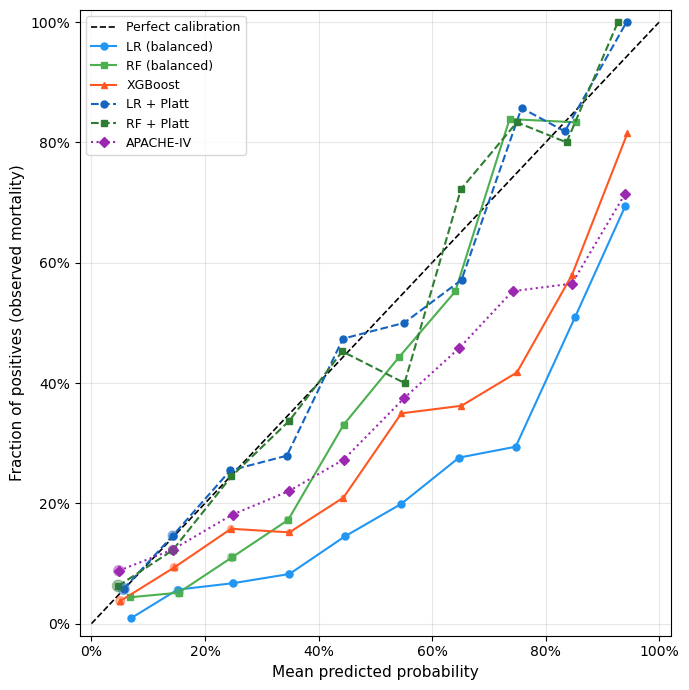

Saved PDF: C:\ML PROJECT\sepsis-gp\results\figures\NB08_calibration_curves.pdf
Saved PNG: C:\ML PROJECT\sepsis-gp\results\figures\NB08_calibration_curves.png


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from src.metrics import calibration_bins

STYLES = {
    "LR"       : {"color": "#2196F3", "marker": "o", "ls": "-",  "lw": 1.5, "label": "LR (balanced)"},
    "RF"       : {"color": "#4CAF50", "marker": "s", "ls": "-",  "lw": 1.5, "label": "RF (balanced)"},
    "XGB"      : {"color": "#FF5722", "marker": "^", "ls": "-",  "lw": 1.5, "label": "XGBoost"},
    "LR_platt" : {"color": "#1565C0", "marker": "o", "ls": "--", "lw": 1.5, "label": "LR + Platt"},
    "RF_platt" : {"color": "#2E7D32", "marker": "s", "ls": "--", "lw": 1.5, "label": "RF + Platt"},
    "APACHE-IV": {"color": "#9C27B0", "marker": "D", "ls": ":",  "lw": 1.5, "label": "APACHE-IV"},
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect calibration", zorder=1)

for name in ["LR", "RF", "XGB", "LR_platt", "RF_platt"]:
    p = np.clip(test_preds[name], 1e-7, 1 - 1e-7)
    c, a, s = calibration_bins(y_test, p)
    st = STYLES[name]
    ax.scatter(c, a, s=s / 15, color=st["color"], alpha=0.4, zorder=3)
    ax.plot(c, a, color=st["color"], marker=st["marker"],
            ls=st["ls"], lw=st["lw"], markersize=5,
            label=st["label"], zorder=2)

ap_p = np.clip(apache_test["apache4_pred"].to_numpy(), 1e-7, 1 - 1e-7)
ap_y = apache_test["hospital_mortality"].to_numpy()
c, a, s = calibration_bins(ap_y, ap_p)
st = STYLES["APACHE-IV"]
ax.scatter(c, a, s=s / 15, color=st["color"], alpha=0.4, zorder=3)
ax.plot(c, a, color=st["color"], marker=st["marker"],
        ls=st["ls"], lw=st["lw"], markersize=5,
        label=st["label"], zorder=2)

ax.set_xlabel("Mean predicted probability", fontsize=11)
ax.set_ylabel("Fraction of positives (observed mortality)", fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_pdf = FIGURES / "NB08_calibration_curves.pdf"
fig_png = FIGURES / "NB08_calibration_curves.png"
fig.savefig(fig_pdf, bbox_inches="tight")
fig.savefig(fig_png, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved PDF: {fig_pdf}")
print(f"Saved PNG: {fig_png}")

### Findings — Cell 4: Calibration curves

---

Saved: `results/figures/NB08_calibration_curves.pdf` and `.png`.

The plot displays six calibration curves against the perfect-calibration diagonal.
Five distinct patterns are visible:

**LR_platt (dark blue dashed) and RF_platt (dark green dashed)** track the diagonal
most closely across all probability bins, consistent with ECE = 0.012 and 0.020
respectively. Calibration slopes near 1.0 (0.936, 0.881) and intercepts near zero
confirm that probability estimates are centred on the true prevalence. Bubble sizes
(proportional to bin count) confirm that the critical low-probability bins (0–20%),
where most patients reside, are well-calibrated for both Platt-scaled models.

**APACHE-IV (purple dotted)** shows reasonable but imperfect calibration (ECE = 0.067).
The high-risk bins (>40%) fall below the diagonal, reflecting systematic over-prediction
of mortality in contemporary ICUs — a known consequence of APACHE-IV being trained on
an older, higher-mortality population.

**RF (solid green)** deviates in mid-range bins with the curve above the diagonal
(calibration slope 1.355, mild underconfidence at high risk). The deviation is
consistent across bins without the large swings seen in LR or XGB.

**XGB (red)** runs below the diagonal at higher predicted probabilities (slope 0.734,
overconfidence), reflecting the scale_pos_weight upweighting which concentrates
predictions above the true prevalence.

**LR (blue)** displays the most severe distortion — the curve departs from the
diagonal throughout, consistent with ECE = 0.260 and Brier skill = −40.0%.
The `class_weight='balanced'` setting has inflated predicted probabilities far above
the true 16.88% prevalence, rendering uncalibrated LR predictions unsuitable as
probability estimates.

In [15]:
# ── baseline_test_predictions.csv ─────────────────────────────────────────────
preds_out = test_df[["patientunitstayid", "hospitalid", "hospital_mortality"]].copy()
for name in ["LR", "RF", "XGB", "LR_platt", "RF_platt"]:
    preds_out[name.lower() + "_pred"] = test_preds[name]
out_preds = DATA_PROC / "baseline_test_predictions.csv"
preds_out.to_csv(out_preds, index=False)
print(f"Saved: {out_preds}  ({len(preds_out):,} rows, "
      f"cols: {list(preds_out.columns)})")

# ── baseline_cv_results.csv ───────────────────────────────────────────────────
out_cv = TABLES / "baseline_cv_results.csv"
cv_df.to_csv(out_cv, index=False)
print(f"Saved: {out_cv}")

# ── baseline_test_metrics.csv ─────────────────────────────────────────────────
out_test = TABLES / "baseline_test_metrics.csv"
compare_df.to_csv(out_test, index=False)
print(f"Saved: {out_test}")

print()
print("=" * 70)
print("NB08 complete — test-set metrics summary:")
print("=" * 70)
print(compare_df[["model","auroc","auprc","brier","brier_skill_pct",
                   "ece_10bin","sensitivity","specificity","f1"]].to_string(index=False))
print()
print("Downstream usage:")
print("  baseline_test_predictions.csv → NB11, NB12, NB13")
print("  baseline_test_metrics.csv     → NB11 (comparison table with GP)")
print("  baseline_cv_results.csv       → NB11 (CV vs test consistency)")

Saved: C:\ML PROJECT\sepsis-gp\data\processed\baseline_test_predictions.csv  (2,233 rows, cols: ['patientunitstayid', 'hospitalid', 'hospital_mortality', 'lr_pred', 'rf_pred', 'xgb_pred', 'lr_platt_pred', 'rf_platt_pred'])
Saved: C:\ML PROJECT\sepsis-gp\results\tables\baseline_cv_results.csv
Saved: C:\ML PROJECT\sepsis-gp\results\tables\baseline_test_metrics.csv

NB08 complete — test-set metrics summary:
    model  auroc  auprc  brier  brier_skill_pct  ece_10bin  sensitivity  specificity     f1
       LR 0.7675 0.4636 0.1964            -40.0     0.2595       0.6817       0.7247 0.4489
       RF 0.7767 0.4737 0.1299              7.5     0.1156       0.6472       0.7904 0.4832
      XGB 0.7679 0.4512 0.1411             -0.5     0.1156       0.5809       0.8125 0.4640
 LR_platt 0.7675 0.4636 0.1168             16.8     0.0117       0.6817       0.7247 0.4489
 RF_platt 0.7767 0.4737 0.1153             17.9     0.0203       0.6472       0.7904 0.4832
APACHE-IV 0.6847 0.3699 0.1336          

### Findings — Cell 5: Outputs saved

---

| File | Location | Rows | Columns |
|---|---|---|---|
| `baseline_test_predictions.csv` | `data/processed/` | 2,233 | 8 (`patientunitstayid`, `hospitalid`, `hospital_mortality`, `lr_pred`, `rf_pred`, `xgb_pred`, `lr_platt_pred`, `rf_platt_pred`) |
| `baseline_cv_results.csv` | `results/tables/` | 3 | LR, RF, XGB CV metrics |
| `baseline_test_metrics.csv` | `results/tables/` | 6 | LR, RF, XGB, LR_platt, RF_platt, APACHE-IV test metrics |
| `NB08_calibration_curves.pdf/.png` | `results/figures/` | — | All 6 models |

**Key Results summary:**

| Rank (AUROC) | Model | AUROC | Brier skill | ECE |
|---|---|---|---|---|
| 1 | RF / RF_platt | 0.777 | +7.5% / +17.9% | 0.116 / **0.020** |
| 2 | LR / LR_platt | 0.768 | −40.0% / +16.8% | 0.260 / **0.012** |
| 3 | XGB | 0.768 | −0.5% | 0.116 |
| 4 | APACHE-IV | 0.685 | +3.4% | 0.067 |

`baseline_test_predictions.csv` now includes `lr_platt_pred` and `rf_platt_pred`
alongside the uncalibrated predictions, providing properly calibrated baseline
comparators for NB11–NB13. NB11 will extend this table with GP predictions and
produce the final 5-model statistical comparison (DeLong tests, ECE forest plot, DCA).